In [241]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import seaborn as sns
import torch
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf
from pathlib import Path

plt.style.use("science")


In [242]:
from pathlib import Path

runs_dir = Path("/home/shihongyue/FourierDiffusionMirror/lightning_logs")
save_dir = Path("/home/shihongyue/FourierDiffusionMirror/outputs")

In [243]:
#runs_dir = Path.cwd() / "../lightning_logs/"
#save_dir = Path.cwd() / "outputs/"


if not (save_dir / "figures").exists():
    (save_dir / "figures").mkdir(parents=True)

#set torch seed and numpy seed
rand_gen = torch.Generator()
rand_gen.manual_seed(0)




In [244]:
def ordering(name):
    if name == "train":
        return 0
    elif name == "freq":
        return 1
    elif name == "time":
        return 2
    else:
        return 3


LEGEND_MAPPING = {"train": "Training samples", "freq": "Generated samples (Frequency domain model)",
                  "time": "Generated samples (Time domain model)"}


def plot_samples(samples_dic, n_samples):
    n_columns = len(samples_dic.keys())
    #Plot samples 
    fig, ax = plt.subplots(n_samples, n_columns, figsize=(5 * n_samples, 10 * n_columns))
    for k in range(n_samples):
        for i, (domain, samples) in enumerate(sorted(samples_dic.items(), key=lambda x: ordering(x[0]))):
            for j in range(samples.shape[-1]):
                ax[k, i].plot(samples[k, :, j], label=f"Feature {j}")
            ax[k, i].legend(fontsize=15)
            ax[0, i].set_title(LEGEND_MAPPING[domain], fontsize=25)

    return fig, ax


def heatmap_samples(samples_dic, n_samples):
    n_columns = len(samples_dic.keys())
    #Plot samples 
    fig, ax = plt.subplots(n_samples, n_columns, figsize=(5 * n_samples, 10 * n_columns))
    for k in range(n_samples):
        for i, (domain, samples) in enumerate(sorted(samples_dic.items(), key=lambda x: ordering(x[0]))):
            max_val = torch.abs(samples[k]).max(dim=0)[0].max(dim=0)[0]
            min_val = torch.abs(samples[k]).min(dim=0)[0].min(dim=0)[0]
            sns.heatmap(samples[k].transpose(1, 0), cmap="RdBu_r", vmin=min_val, vmax=max_val, ax=ax[k, i])
            ax[0, i].set_title(LEGEND_MAPPING[domain], fontsize=25)
    return fig, ax

In [245]:
def get_train_samples(model_id):
    #with initialize(version_base=None, config_path="../lightning_logs/"+model_id):
    with initialize(
            version_base=None,
            config_path=f"lightning_logs/{model_id}",
            job_name="get_train_samples"
    ):
        train_config = compose(config_name="train_config")
        train_config.datamodule.data_dir = Path.cwd() / "data"
        datamodule = instantiate(train_config.datamodule)
        datamodule.prepare_data()
        datamodule.setup("plot")
        train_samples = datamodule.X_train
        return train_samples

In [246]:
def get_train_samples(model_id):
    import os
    from pathlib import Path
    from omegaconf import OmegaConf
    from hydra.utils import instantiate

    # 设置路径（你的项目根目录）
    os.chdir("/home/shihongyue/FourierDiffusionMirror")

    # ✅ 加载保存好的配置快照（不再用 Hydra 初始化）
    config_path = f"lightning_logs/{model_id}/train_config.yaml"
    train_config = OmegaConf.load(config_path)

    # ✅ 修正数据路径
    train_config.datamodule.data_dir = Path("/home/shihongyue/FourierDiffusionMirror/data")

    # ✅ 实例化并加载数据
    datamodule = instantiate(train_config.datamodule)
    datamodule.prepare_data()
    datamodule.setup("plot")

    return datamodule.X_train


In [247]:
#def get_train_samples(model_id):
#import os
#from hydra import initialize, compose
#from omegaconf import OmegaConf

# 切换到包含 config 的目录作为根路径
#/home/shi/FourierDiffusion/lightning_logs
#config_dir = f"lightning_logs/{model_id}"
#os.chdir("/home/shi/FourierDiffusion")  # 这里是你的项目根目录

#with initialize(version_base=None, config_path=config_dir, job_name="get_train_samples"):
#train_config = compose(config_name="train_config")

# 设置正确的数据路径
#train_config.datamodule.data_dir = Path("/home/shi/FourierDiffusion/data")
#datamodule = instantiate(train_config.datamodule)
#datamodule.prepare_data()
#datamodule.setup("plot")

#return datamodule.X_train

In [248]:
runs_dir

PosixPath('/home/shihongyue/FourierDiffusionMirror/lightning_logs')

In [249]:
from pathlib import Path

data_path = Path("/home/shihongyue/FourierDiffusionMirror/data")

In [250]:
import os

tinytex_bin = os.path.expanduser("~/.TinyTeX/bin/x86_64-linux")
os.environ["PATH"] = f"{tinytex_bin}:{os.environ['PATH']}"


In [251]:
import shutil
print(shutil.which("dvipng"))

/home/shihongyue/.TinyTeX/bin/x86_64-linux/dvipng


In [252]:
import matplotlib as mpl
mpl.rcParams["text.usetex"] = False

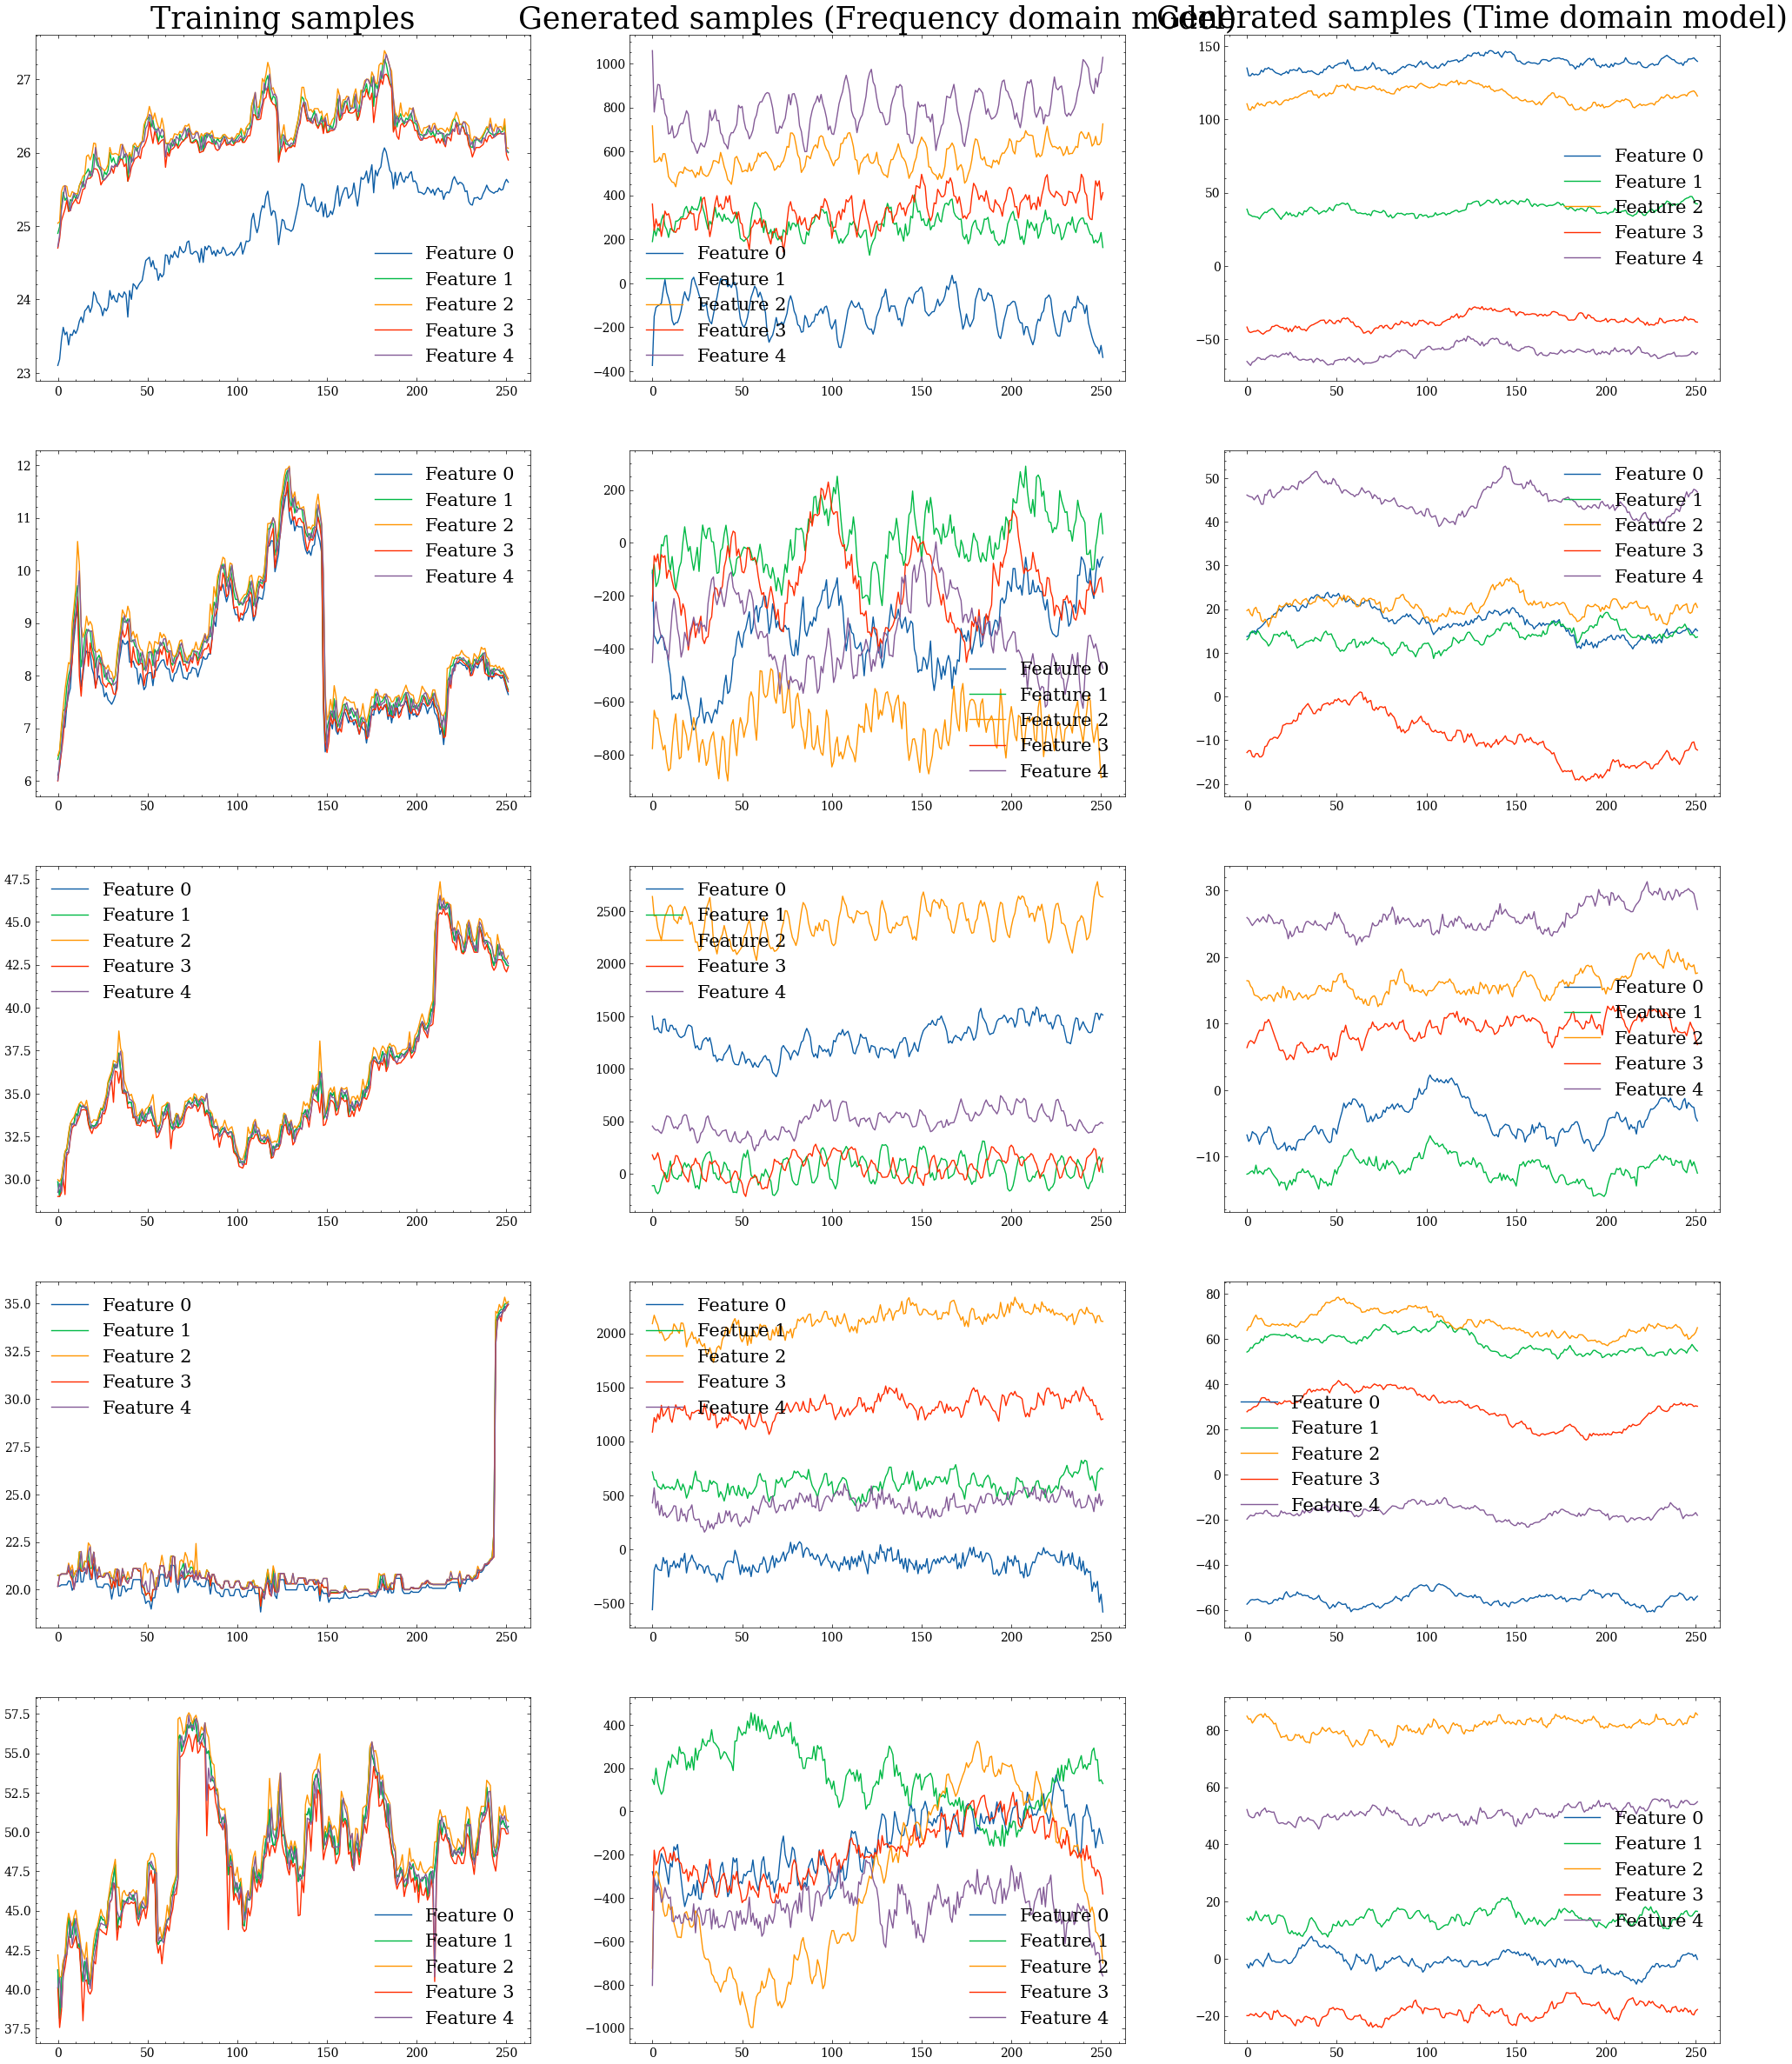

In [253]:
from pathlib import Path

# Plot samples for the NASA charge dataset
#model_ids = {"freq": "20d9c1kc", "time": "tip2g8eh"}
#/home/shi/FourierDiffusion/lightning_logs/d8zpnrfo
model_ids = {"freq": "5u8h8dgs", "time": "67hxlx54"}
samples_dic = {}
n_samples = 5

for domain, id in model_ids.items():
    path_samples = runs_dir / id / "samples.pt"
    samples_dic[domain] = torch.load(path_samples)
    #shuffle
    samples_dic[domain] = samples_dic[domain][torch.randperm(samples_dic[domain].shape[0], generator=rand_gen)]

train_samples = get_train_samples(model_ids["freq"])
samples_dic["train"] = train_samples

#shuffle
samples_dic["train"] = samples_dic["train"][torch.randperm(samples_dic["train"].shape[0], generator=rand_gen)]

fig, ax = plot_samples(samples_dic, n_samples)
fig.savefig(save_dir / "figures" / "nasa_charge_samples.pdf", bbox_inches="tight")
plt.show()


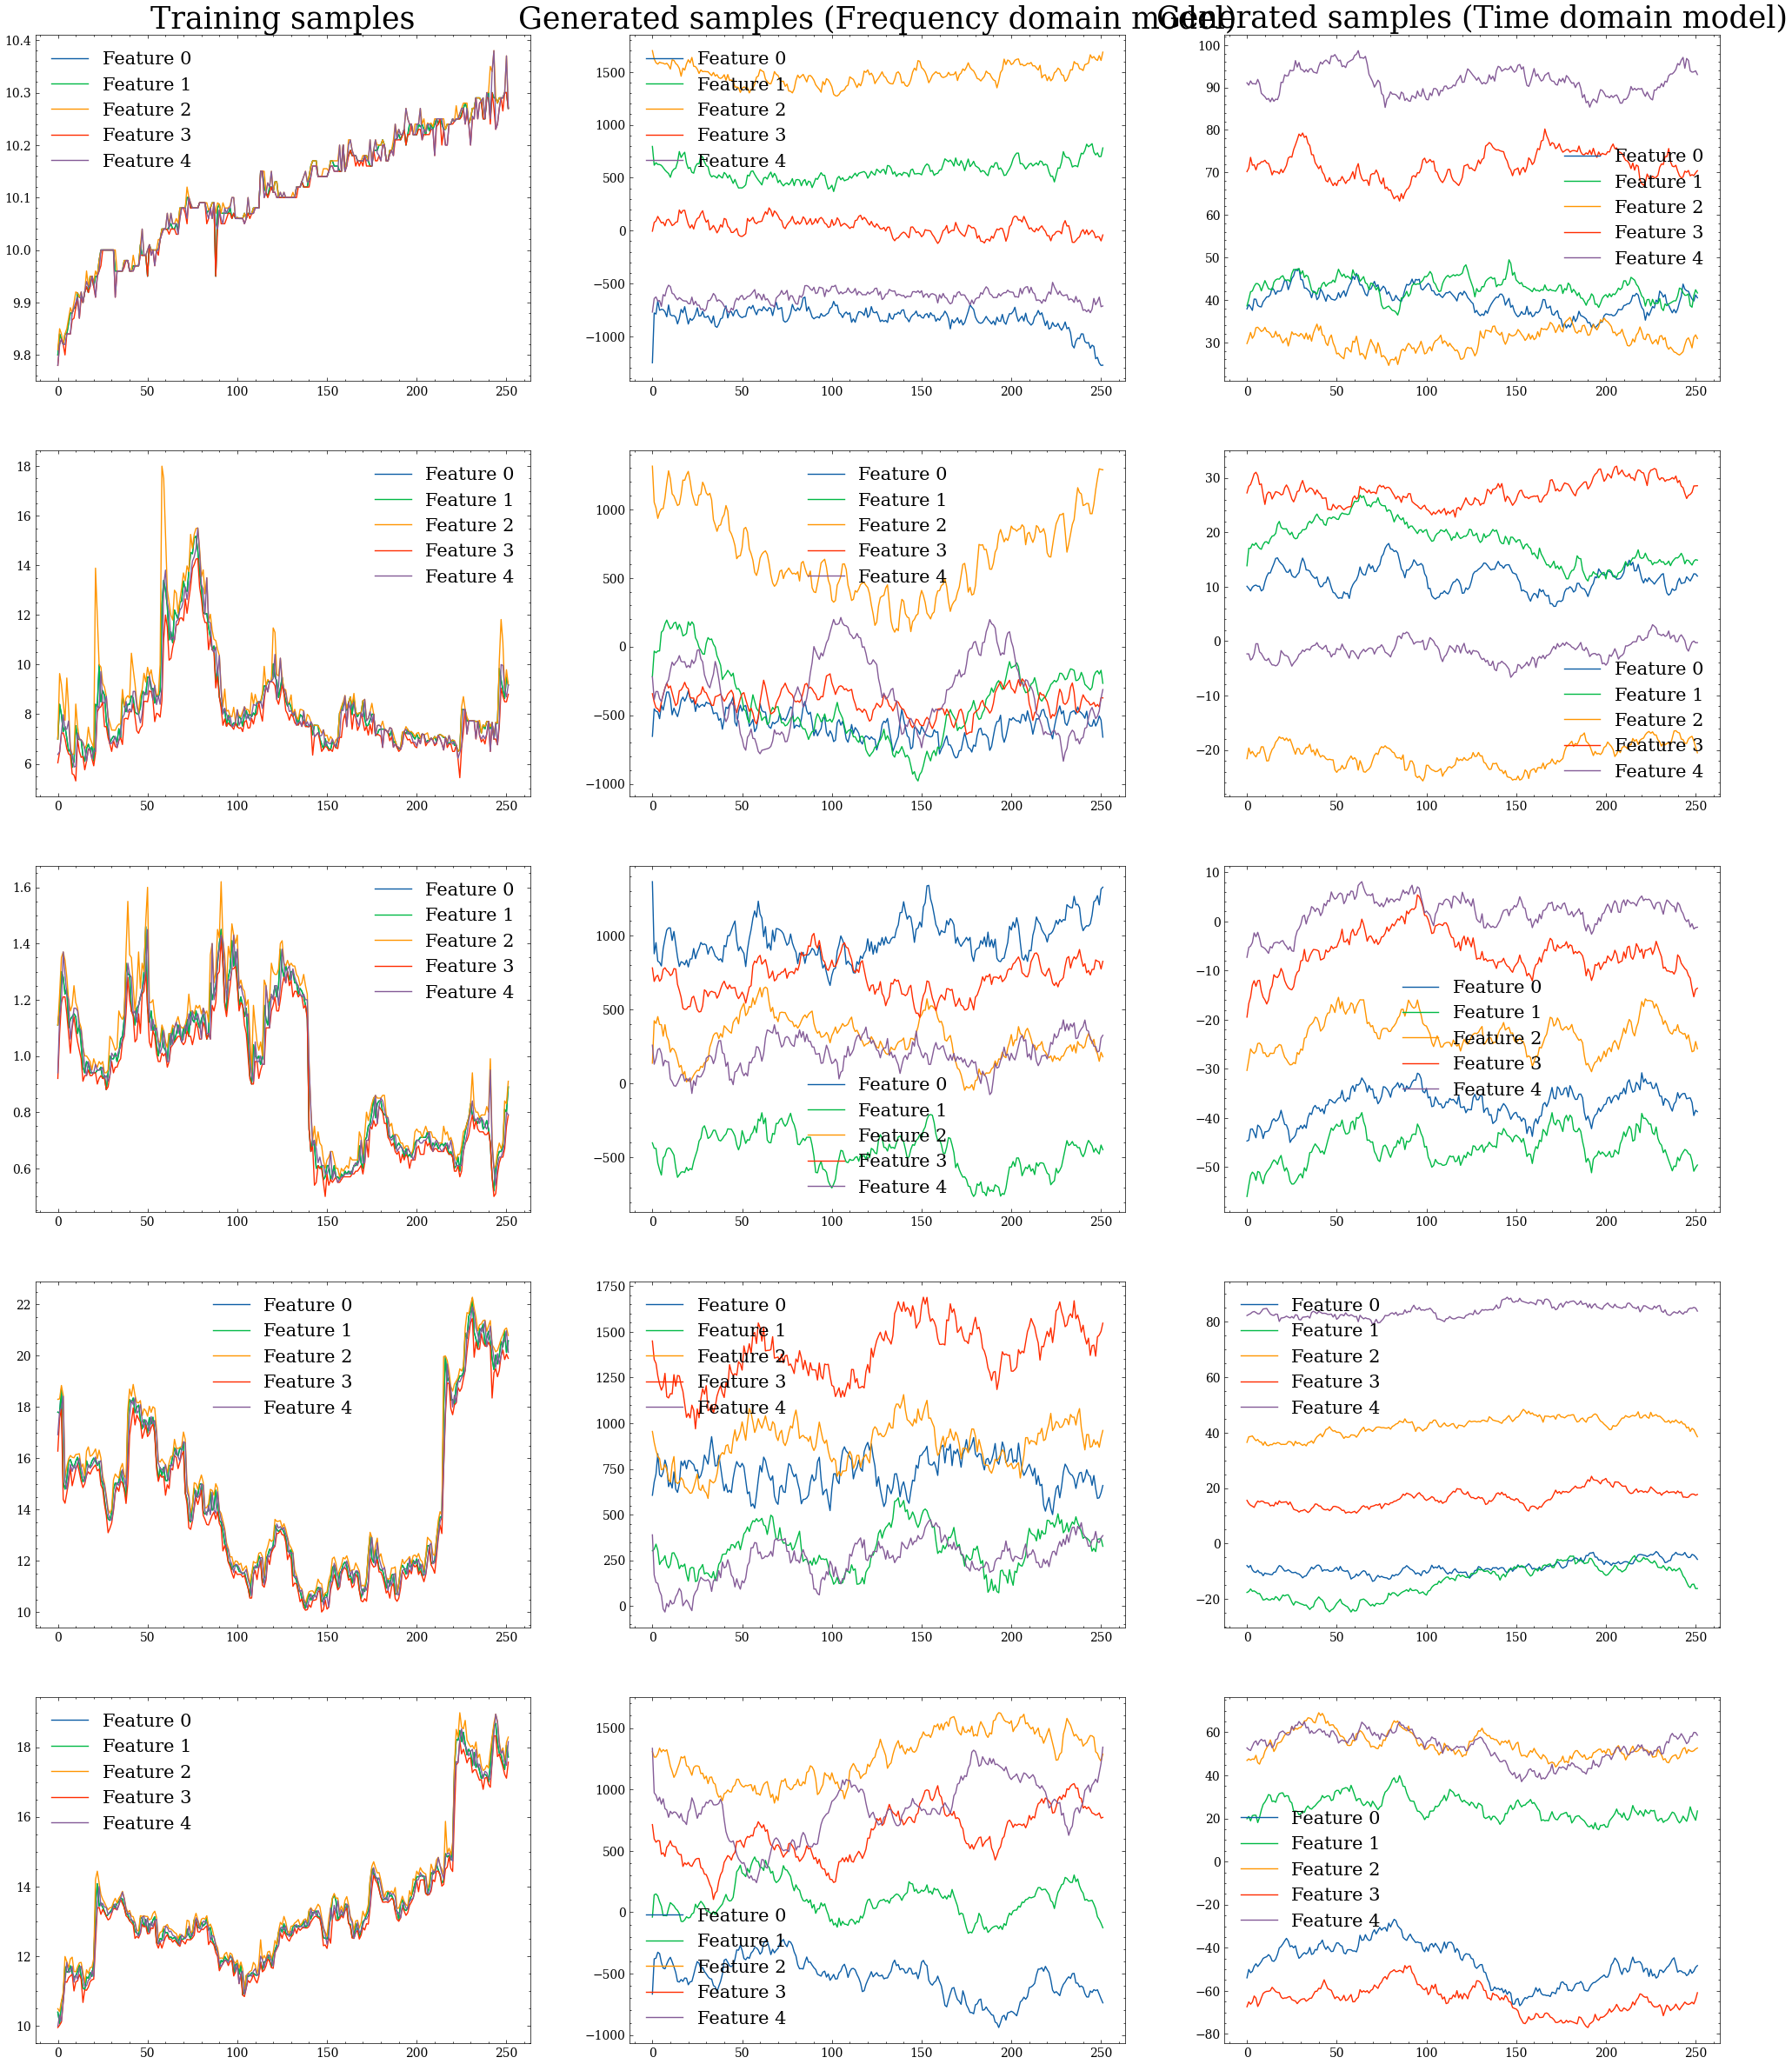

In [254]:
# Plot samples for the NASA discharge dataset
#model_ids = {"freq": "qdzk36m7", "time": "hxoxvper"}
model_ids = {"freq": "5u8h8dgs", "time": "67hxlx54"}
samples_dic = {}
n_samples = 5

for domain, id in model_ids.items():
    path_samples = runs_dir / id / "samples.pt"
    samples_dic[domain] = torch.load(path_samples)
    #shuffle samples
    samples_dic[domain] = samples_dic[domain][torch.randperm(samples_dic[domain].shape[0], generator=rand_gen)]

train_samples = get_train_samples(model_ids["freq"])
samples_dic["train"] = train_samples
#shuffle
samples_dic["train"] = samples_dic["train"][torch.randperm(samples_dic["train"].shape[0], generator=rand_gen)]

fig, ax = plot_samples(samples_dic, n_samples)
fig.savefig(save_dir / "figures" / "nasa_discharge_samples.pdf", bbox_inches="tight")
plt.show()

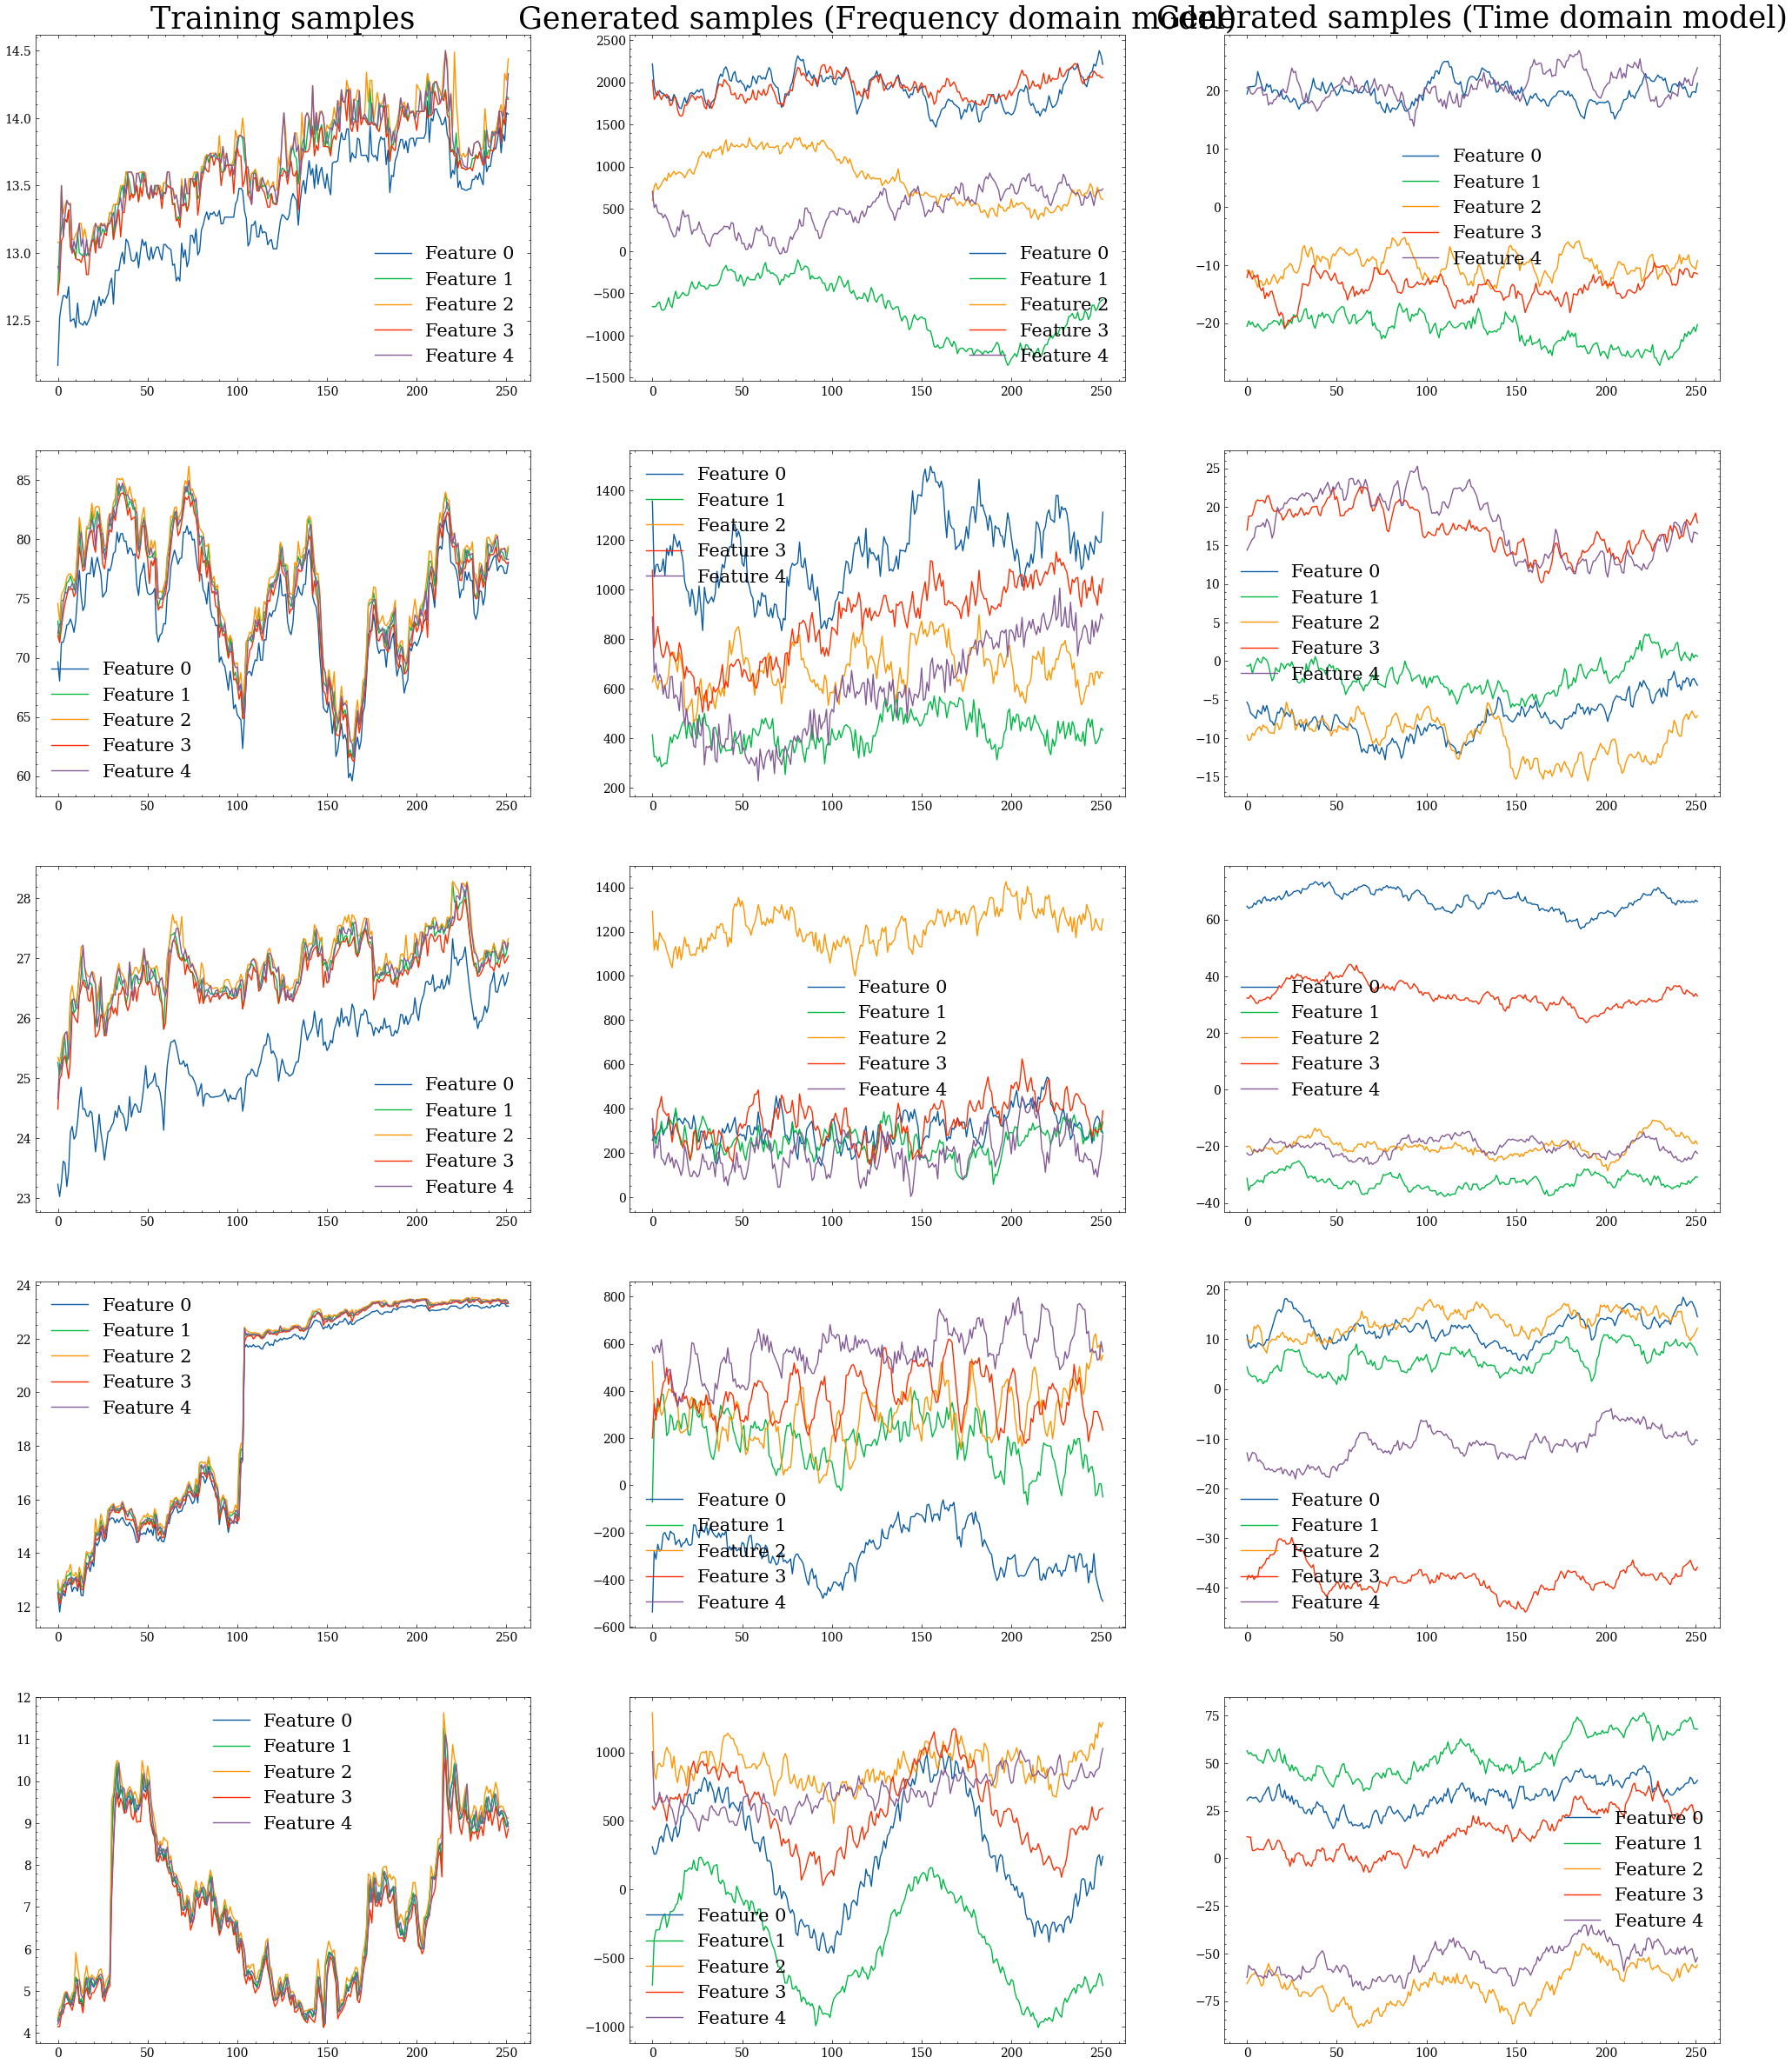

In [255]:
# Plot samples for the ECG dataset
#model_ids = {"freq": "emk7nyz3" , "time": "bf3lrfx9"}
model_ids = {"freq": "5u8h8dgs", "time": "67hxlx54"}
n_samples = 5
samples_dic = {}

for domain, id in model_ids.items():
    path_samples = runs_dir / id / "samples.pt"
    samples_dic[domain] = torch.load(path_samples)

    #Shuffle
    samples_dic[domain] = samples_dic[domain][torch.randperm(samples_dic[domain].shape[0], generator=rand_gen)]

train_samples = get_train_samples(model_ids["freq"])
samples_dic["train"] = train_samples
#shuffle
samples_dic["train"] = samples_dic["train"][torch.randperm(samples_dic["train"].shape[0], generator=rand_gen)]
fig, ax = plot_samples(samples_dic, n_samples)
fig.savefig(save_dir / "figures" / "ECG_samples.pdf", bbox_inches="tight")
plt.show()

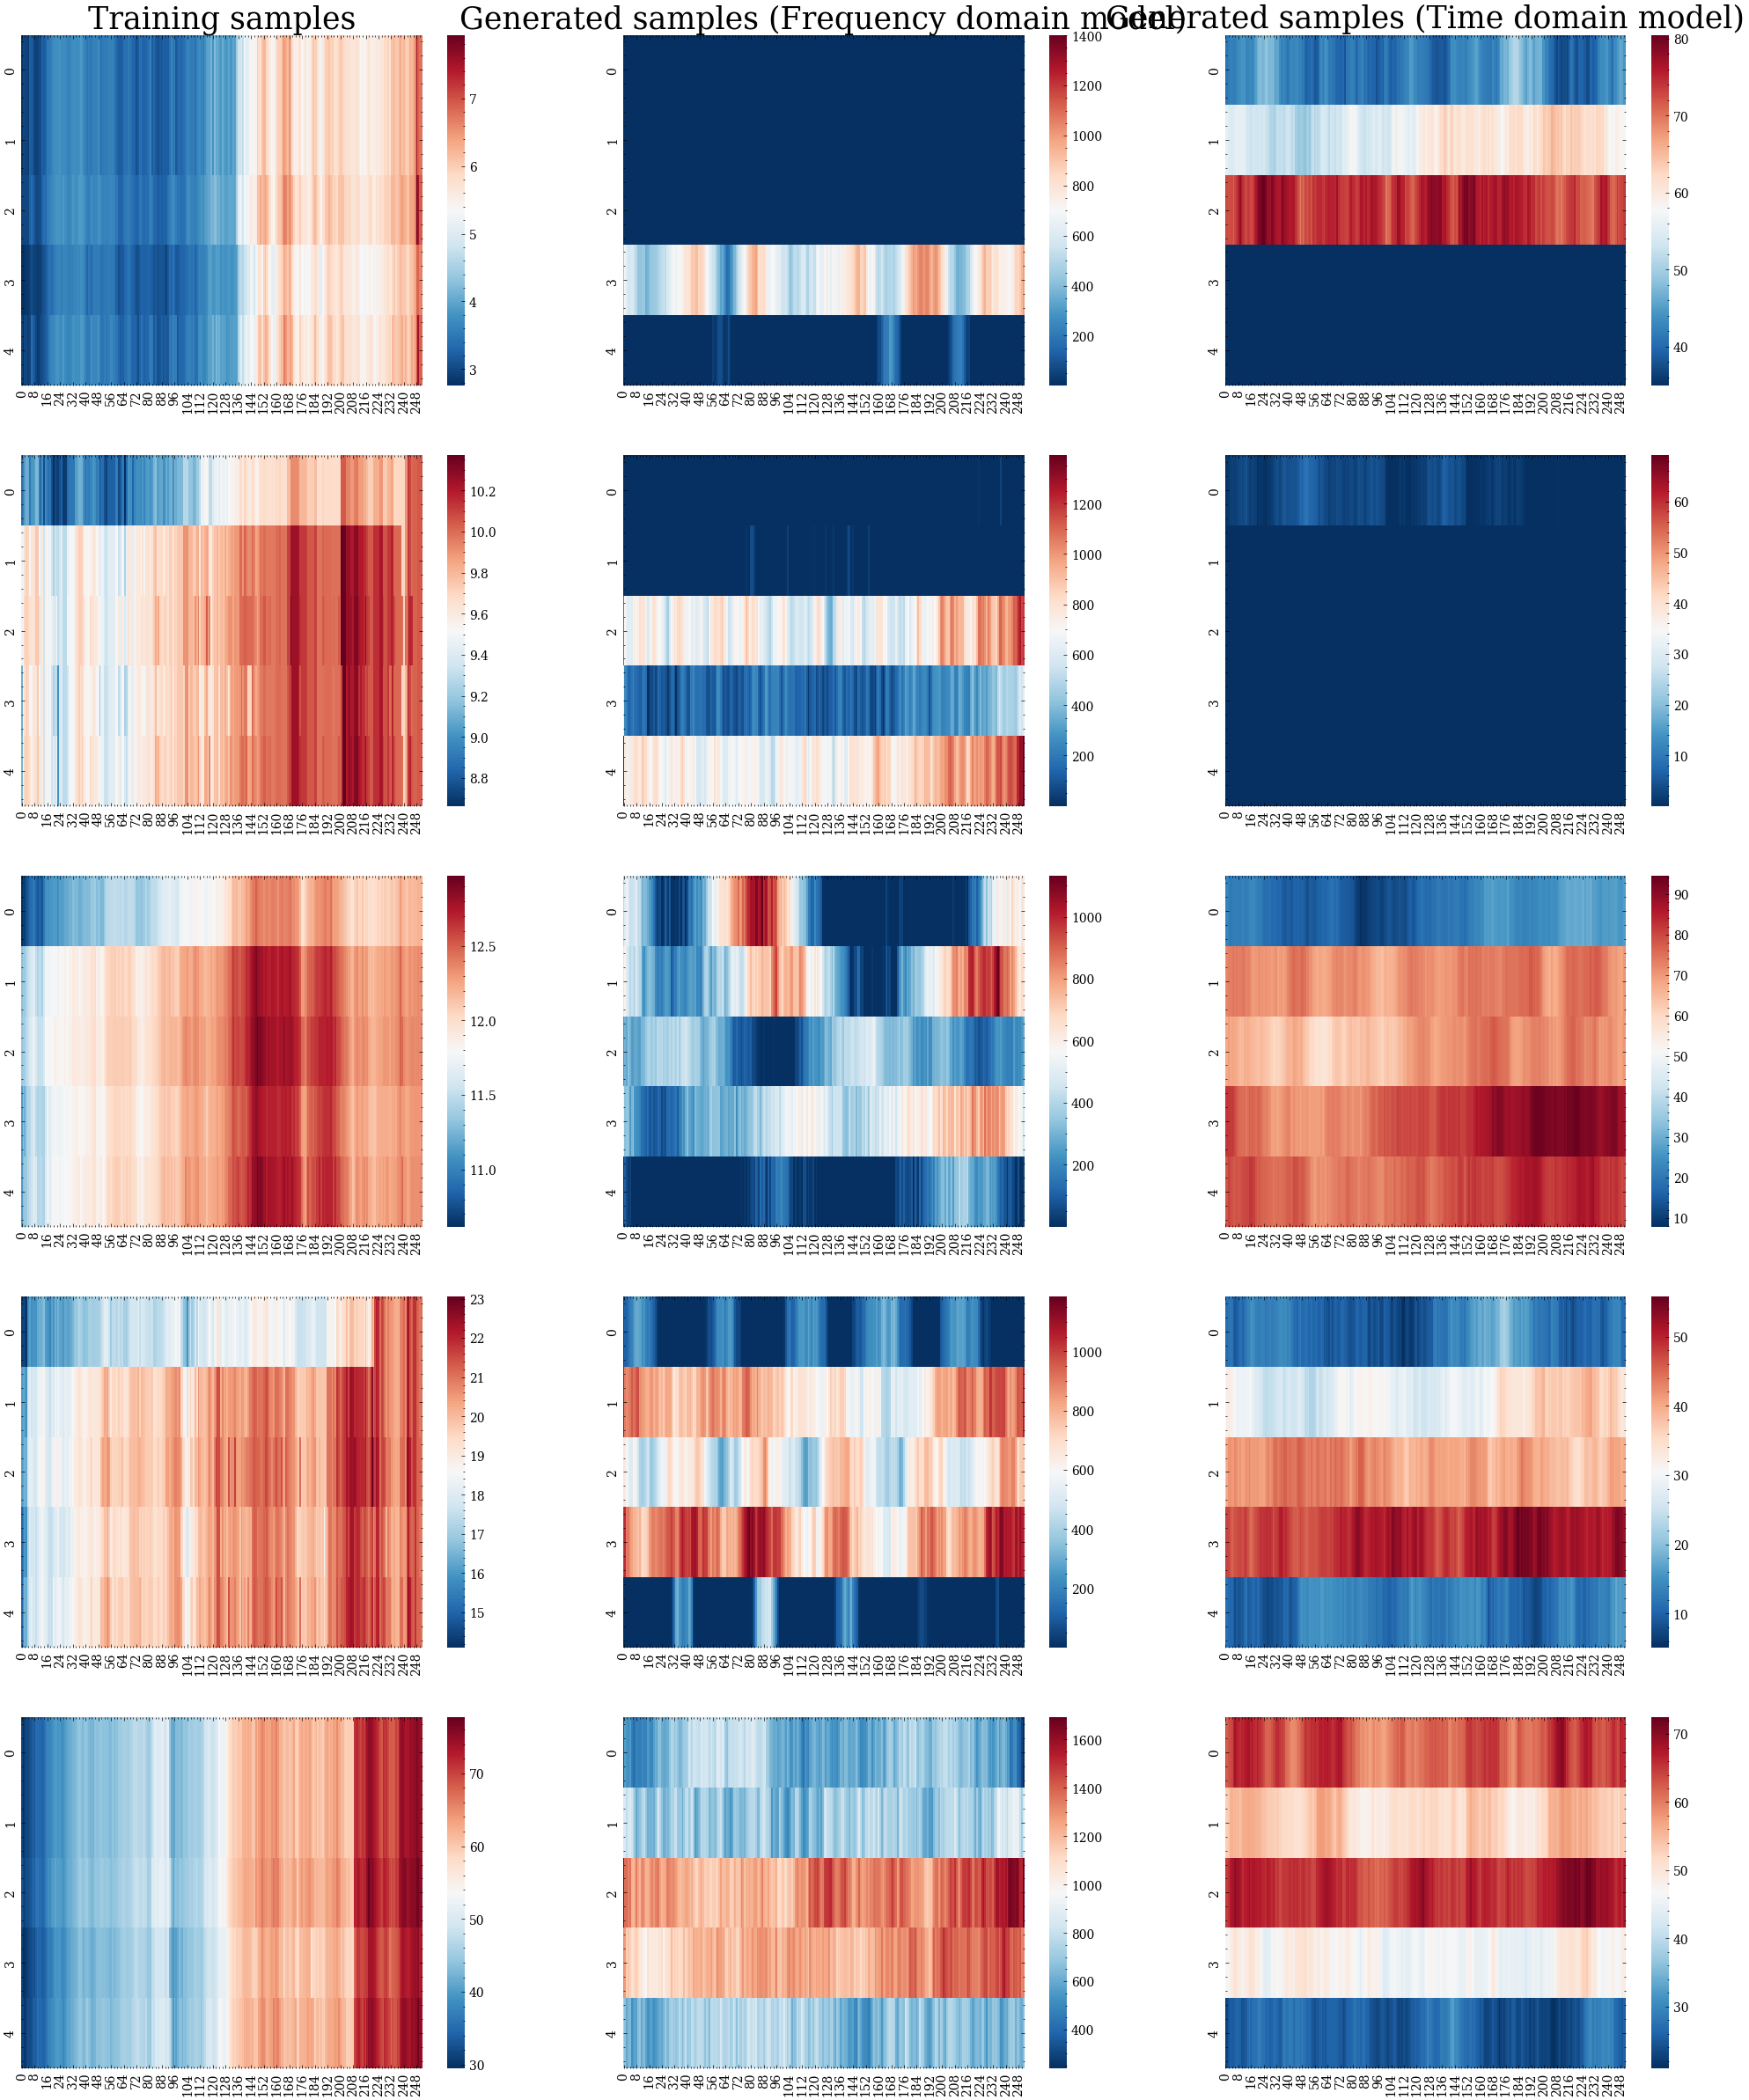

In [256]:
#mimic 
#model_ids = {"freq": "wdwxc4fg", "time": "amxdfaoo"}
model_ids = {"freq": "5u8h8dgs", "time": "67hxlx54"}
n_samples = 5
samples_dic = {}

for domain, id in model_ids.items():
    path_samples = runs_dir / id / "samples.pt"
    samples_dic[domain] = torch.load(path_samples)
    #shuffle
    samples_dic[domain] = samples_dic[domain][torch.randperm(samples_dic[domain].shape[0], generator=rand_gen)]

train_samples = get_train_samples(model_ids["freq"])
samples_dic["train"] = train_samples
#shuffle
samples_dic["train"] = samples_dic["train"][torch.randperm(samples_dic["train"].shape[0], generator=rand_gen)]

fig, ax = heatmap_samples(samples_dic, n_samples)
fig.savefig(save_dir / "figures" / "mimic_samples.pdf", bbox_inches="tight")
fig.savefig(save_dir / "figures" / "mimic_samples.png", bbox_inches="tight")
plt.show()

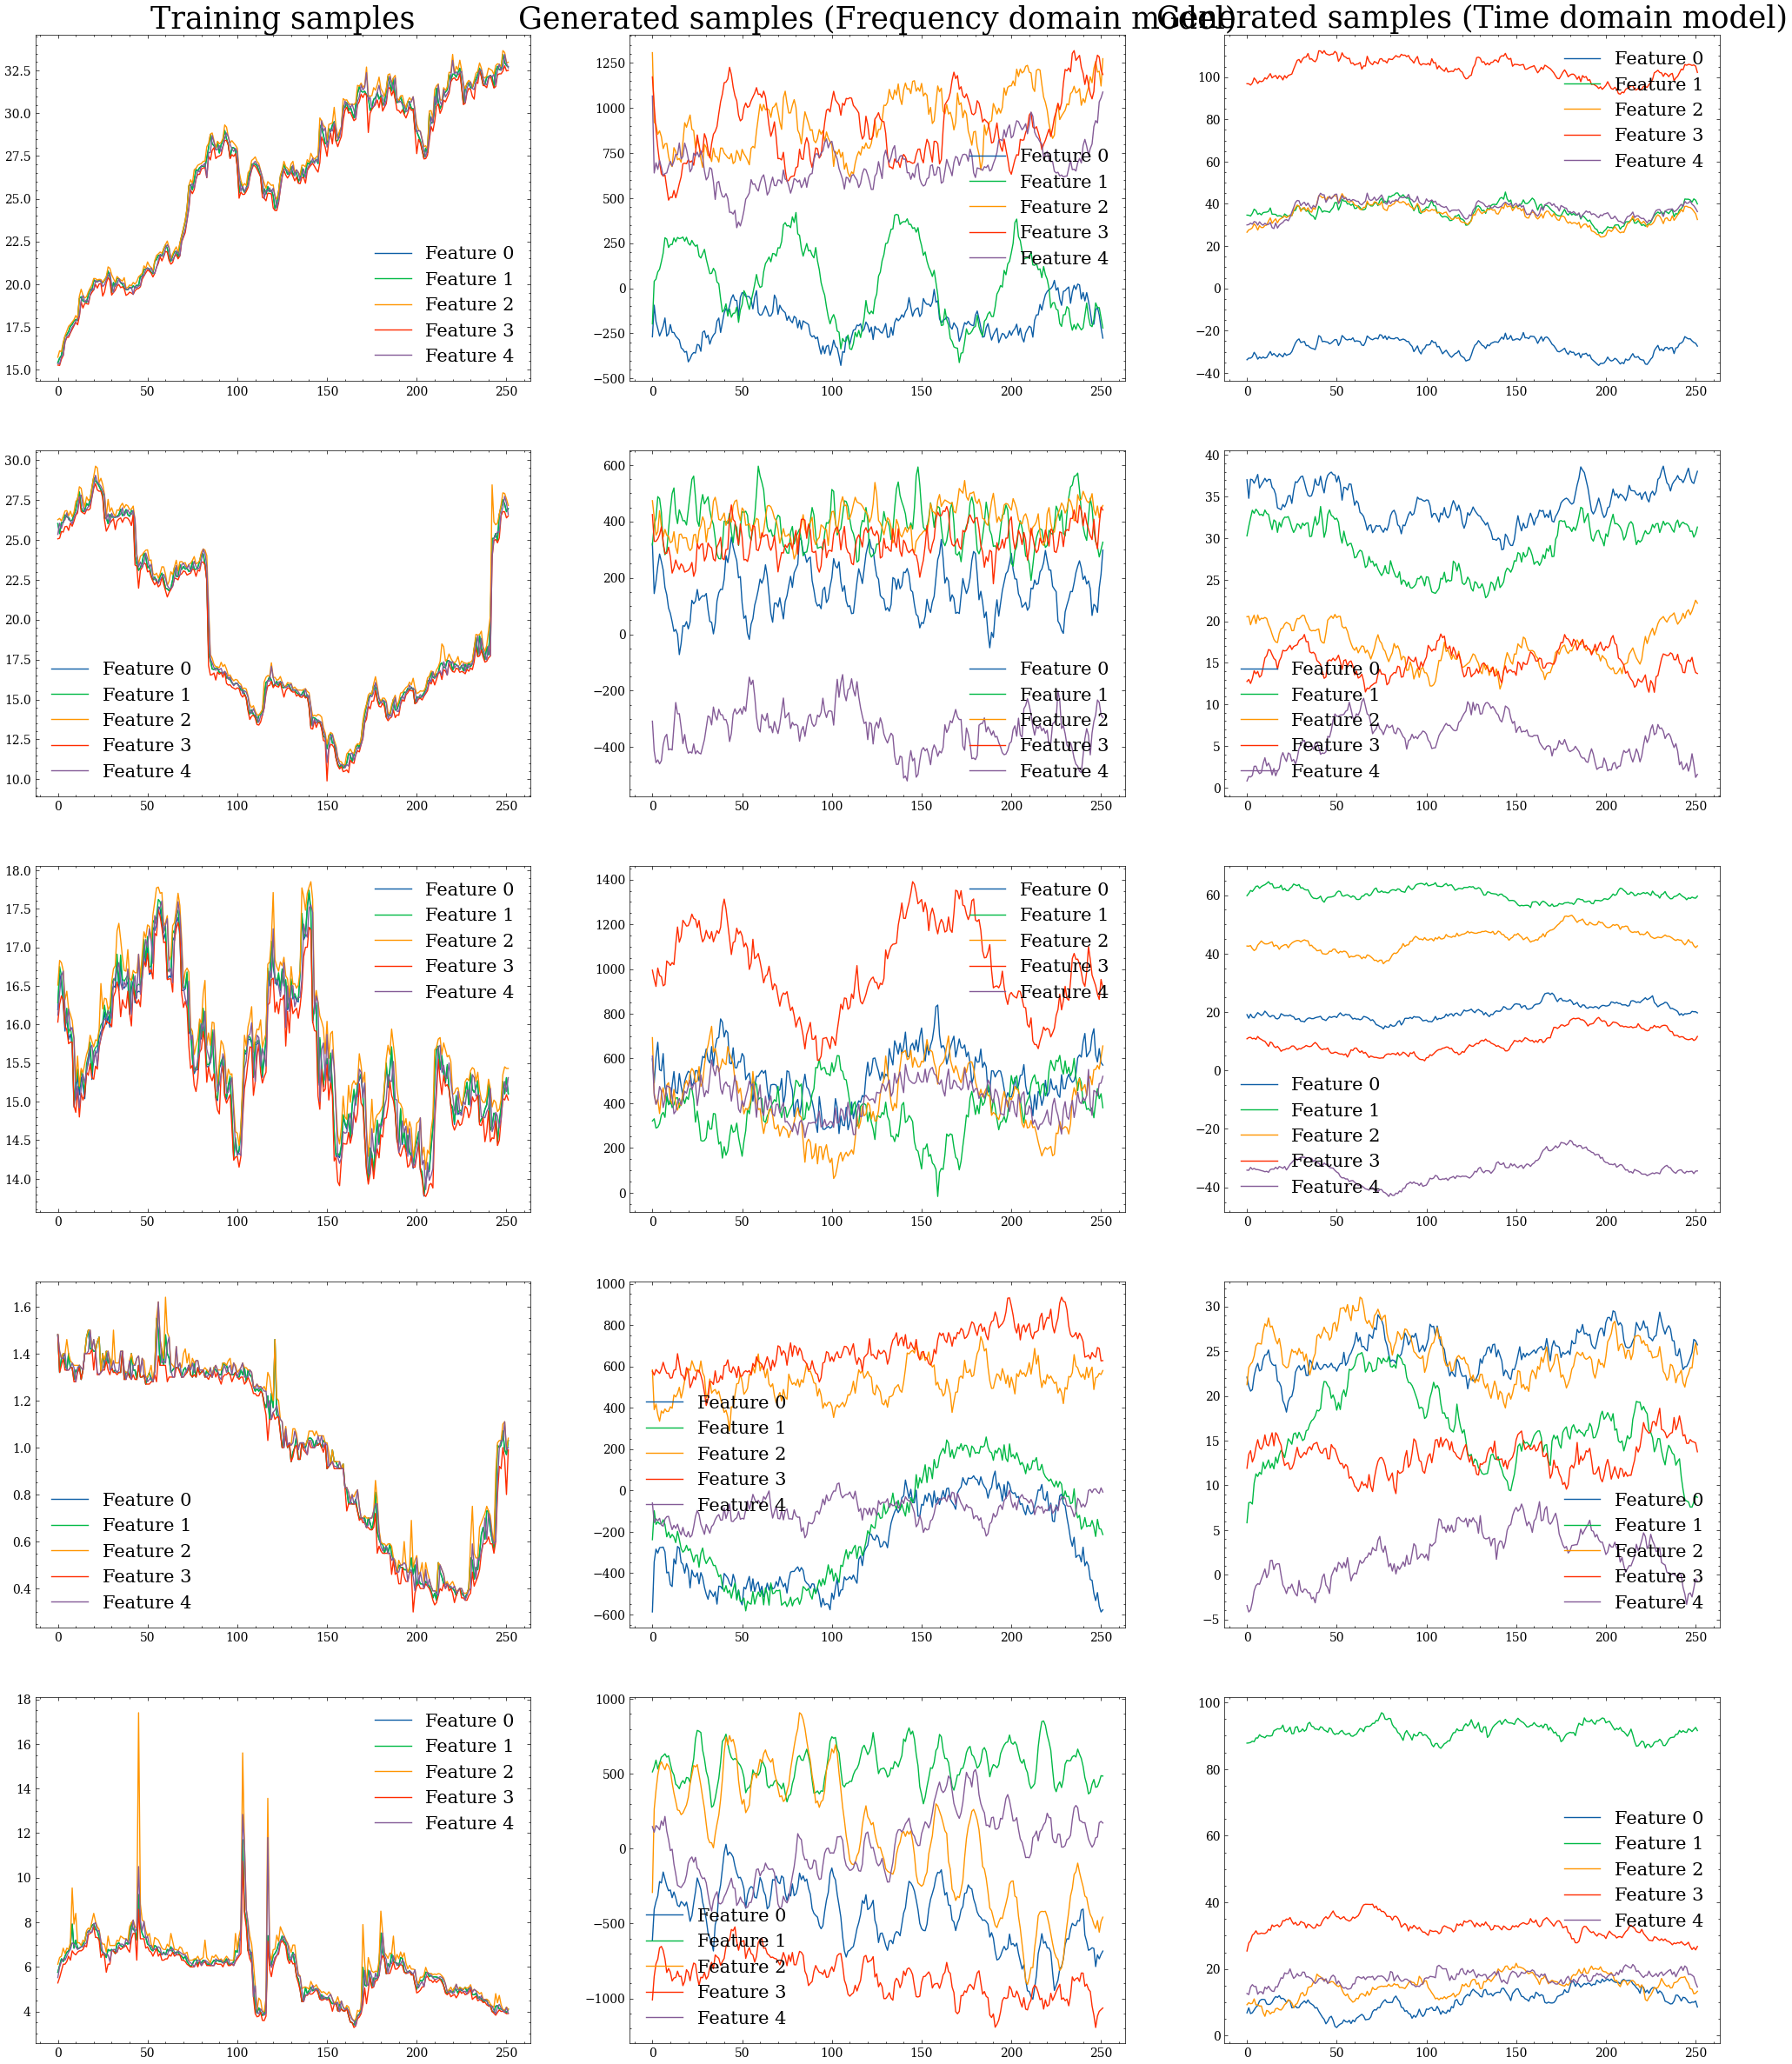

In [257]:
#Nasdaq 
#model_ids = {"freq": "xxqse6xu", "time": "na9xdfui"}
model_ids = {"freq": "5u8h8dgs", "time": "67hxlx54"}
samples_dic = {}
n_samples = 5

for domain, id in model_ids.items():
    path_samples = runs_dir / id / "samples.pt"
    samples_dic[domain] = torch.load(path_samples)
    #shuffle
    samples_dic[domain] = samples_dic[domain][torch.randperm(samples_dic[domain].shape[0], generator=rand_gen)]

train_samples = get_train_samples(model_ids["freq"])

samples_dic["train"] = train_samples
samples_dic["train"] = samples_dic["train"][torch.randperm(samples_dic["train"].shape[0], generator=rand_gen)]

fig, ax = plot_samples(samples_dic, n_samples)
fig.savefig(save_dir / "figures" / "nasdaq_samples.pdf", dpi=300, bbox_inches="tight", format='pdf')
plt.show()

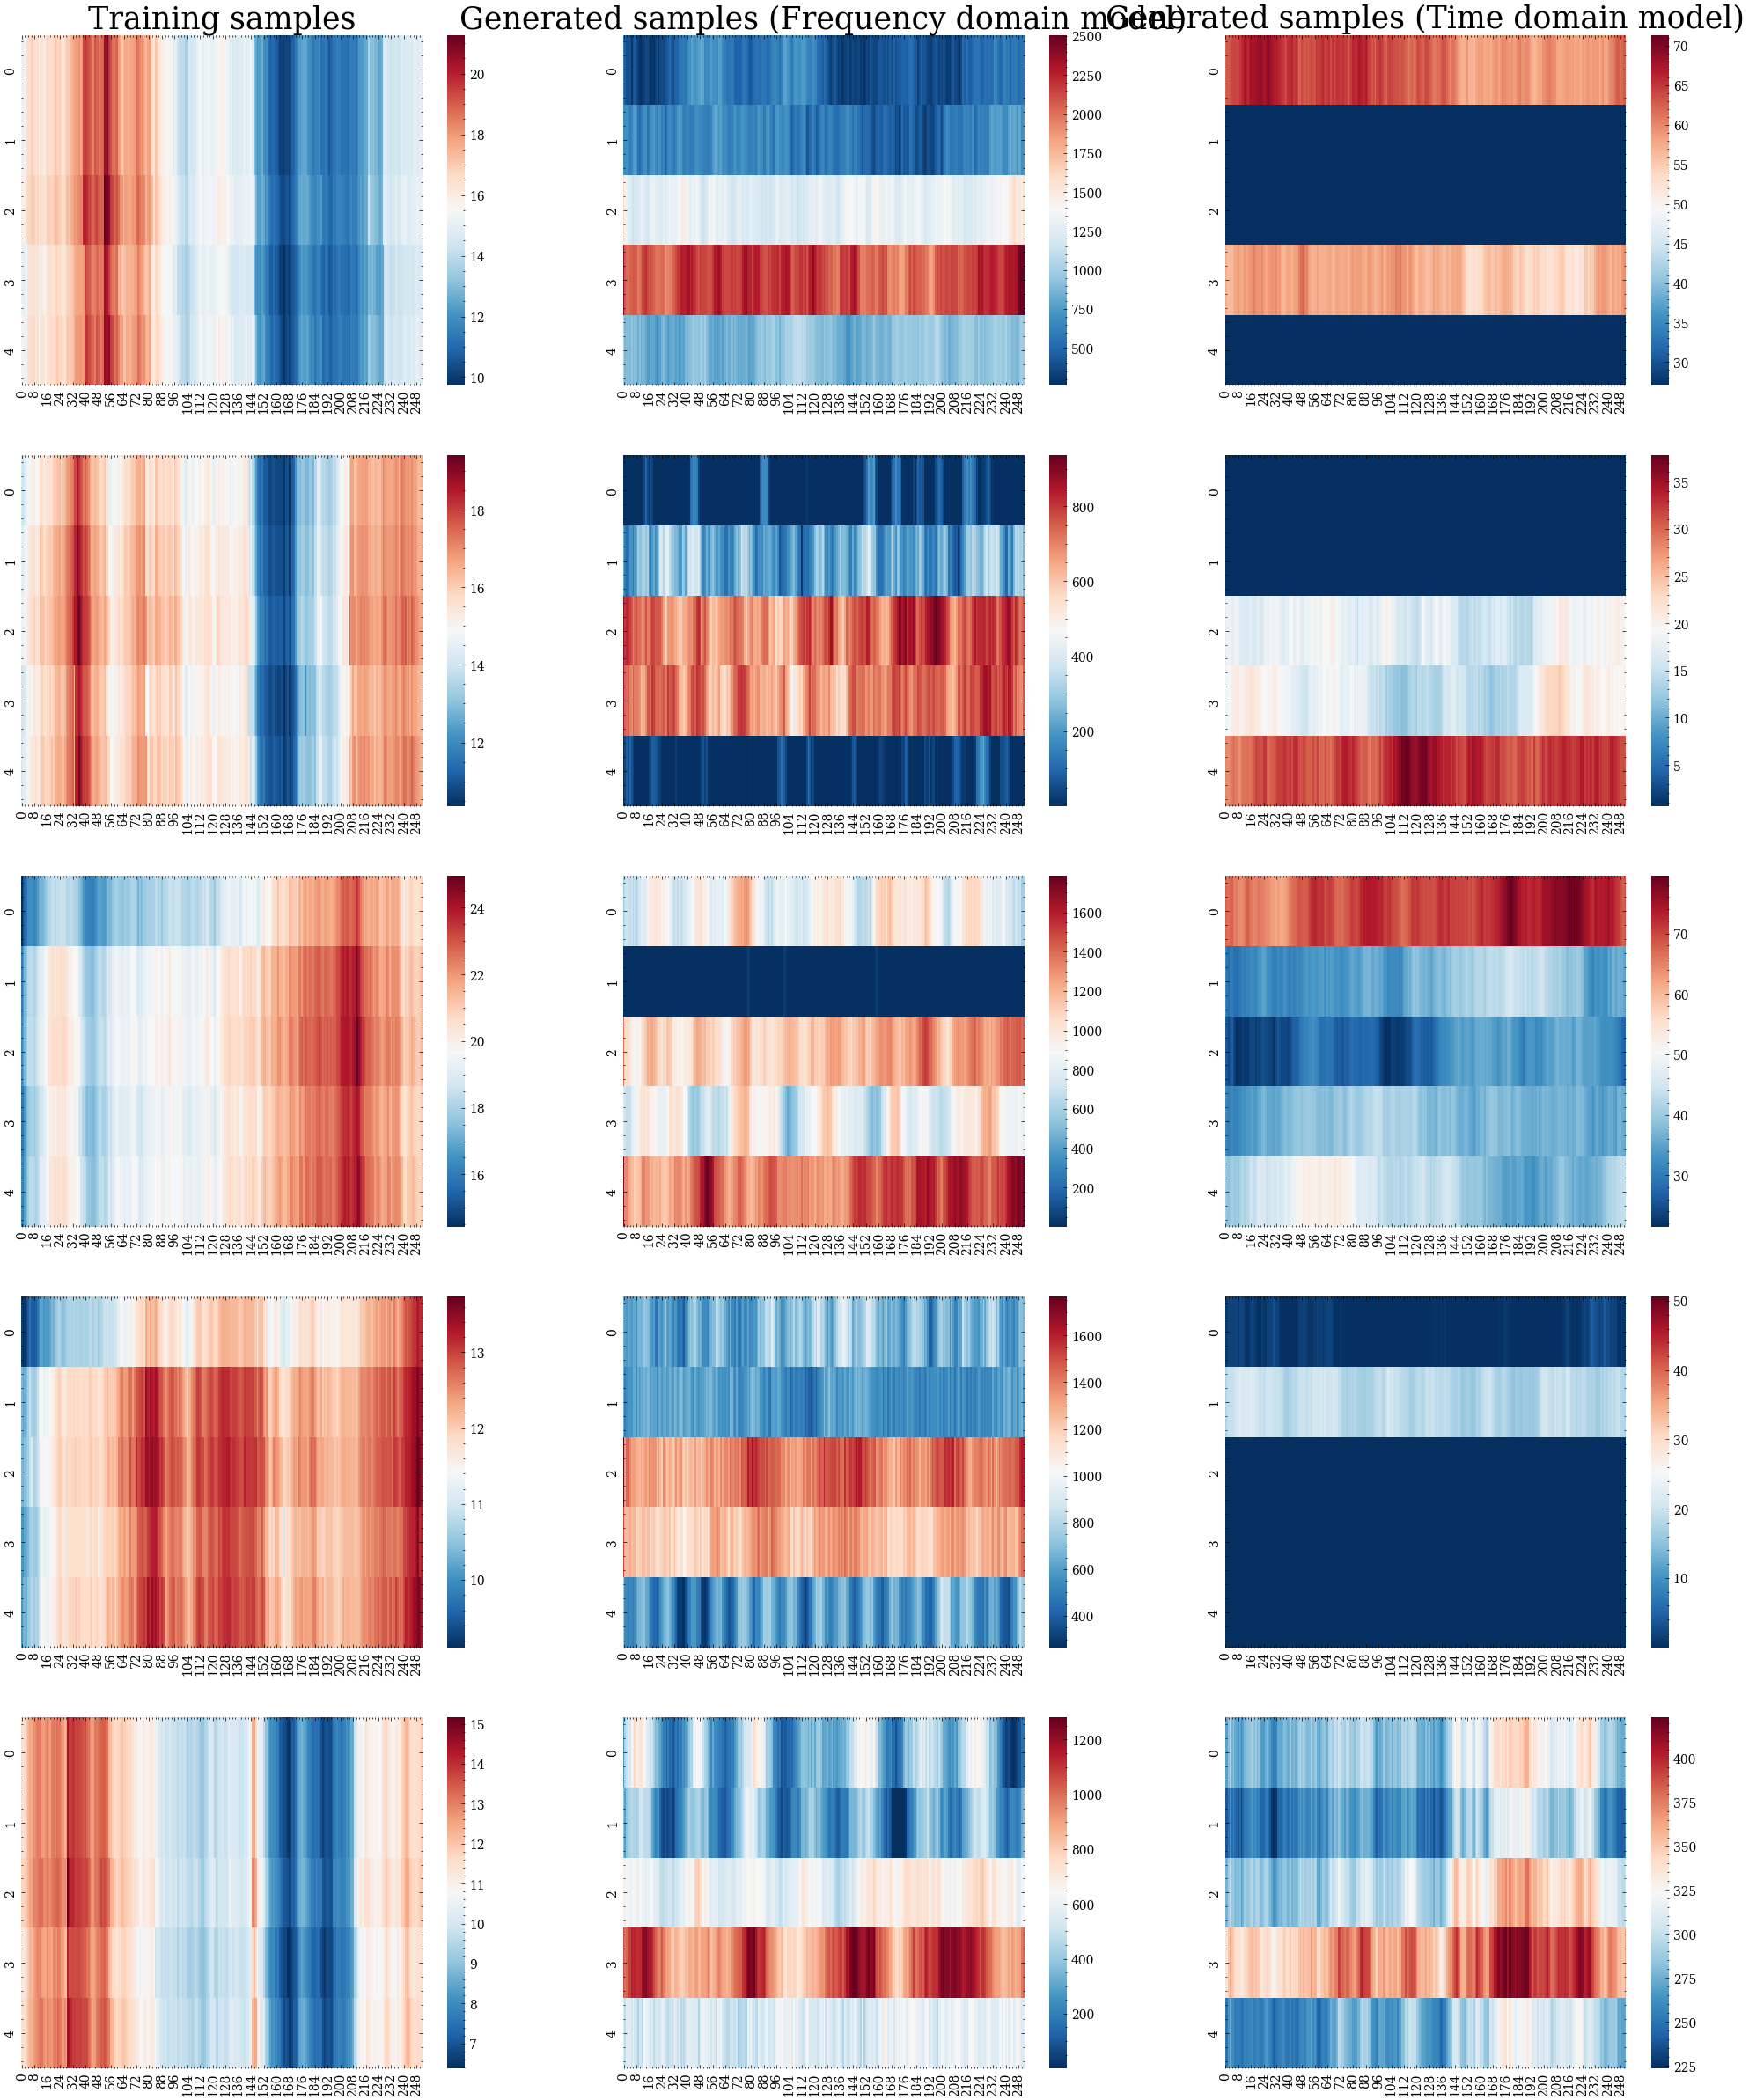

In [258]:
#drought
#model_ids = {"freq": "j5l1t49d" , "time": "pkjeomys"}
model_ids = {"freq": "5u8h8dgs", "time": "67hxlx54"}
samples_dic = {}
n_samples = 5
for domain, id in model_ids.items():
    path_samples = runs_dir / id / "samples.pt"

    samples_dic[domain] = torch.load(path_samples)
    #shuffle
    samples_dic[domain] = samples_dic[domain][torch.randperm(samples_dic[domain].shape[0], generator=rand_gen)]

train_samples = get_train_samples(model_ids["freq"])

samples_dic["train"] = train_samples
samples_dic["train"] = samples_dic["train"][torch.randperm(samples_dic["train"].shape[0], generator=rand_gen)]

fig, ax = heatmap_samples(samples_dic, n_samples)
fig.savefig(save_dir / "figures" / "drought_samples.pdf", bbox_inches="tight")
fig.savefig(save_dir / "figures" / "drought_samples.png", bbox_inches="tight")
plt.show()
